# 01 · Fundamentos: vectores y similitud coseno

Esta sesión recorre cuatro formas de convertir texto en números, cada una
corrigiendo una limitación concreta de la anterior:

| # | Método | Idea | Limitación que deja pendiente |
|---|--------|------|--------------------------------|
| 1 | Bag-of-Words | contar palabras | "el" pesa igual que "epicentro" |
| 2 | TF-IDF | pesar por rareza | sigue sin saber que rey ≈ monarca |
| 3 | Word2Vec | aprender del contexto | un solo vector para "banco" |
| 4 | Transformers | contextualizar | resuelve el contexto, pero cuesta caro |

La pregunta que guía todo el recorrido: **¿cómo logramos que la distancia
entre dos vectores signifique algo lingüístico?** Antes de vectorizar nada
hace falta fijar dos herramientas: qué es un vector de texto y cómo se mide
el parecido entre dos vectores.

## Corpus de trabajo

Tres frases muy simples, usadas en toda la sesión para que los resultados de
cada método sean comparables entre sí.

In [1]:
corpus = {
    "D1": "el gato duerme en el sofá",
    "D2": "el perro duerme en la alfombra",
    "D3": "el sismo sacudió la costa",
}
for doc_id, texto in corpus.items():
    print(f"{doc_id}: {texto!r}")

D1: 'el gato duerme en el sofá'
D2: 'el perro duerme en la alfombra'
D3: 'el sismo sacudió la costa'


**Resultado esperable:** D1 y D2 hablan de animales durmiendo, deberían salir
parecidos; D3 habla de otra cosa y debería quedar lejos de ambos.

**Observación previa:** D1 y D2 comparten las palabras *el · duerme · en*;
D1 y D3 comparten solo *el*. Queda por determinar si contar palabras
compartidas basta para estimar el parecido — ese es, exactamente, el problema
que resuelven los métodos de esta sesión.

## Qué es un vector

Un ejemplo fuera del lenguaje ayuda a fijar la idea: describir canciones
mediante atributos numéricos.

In [2]:
import pandas as pd

canciones = pd.DataFrame(
    {
        "energía": [0.9, 0.8, 0.2],
        "baile": [0.8, 0.9, 0.1],
        "acústica": [0.1, 0.2, 0.9],
        "ánimo": [0.9, 0.8, 0.3],
    },
    index=["Canción A", "Canción B", "Canción C"],
)
canciones

,energía,baile,acústica,ánimo
Canción A,0.9,0.8,0.1,0.9
Canción B,0.8,0.9,0.2,0.8
Canción C,0.2,0.1,0.9,0.3


A y B tienen números parecidos en las cuatro columnas → deberían "sonar
parecido". C es distinta en casi todo → suena a otra cosa. Más abajo se
confirma esta intuición con un número.

**Idea central:** si cada palabra o texto se describe con una lista de
números, el parecido deja de ser una apreciación subjetiva y pasa a ser una
operación calculable. Los métodos que siguen solo difieren en cómo se
obtienen esos números.

## Medir el parecido entre dos vectores

Se usa el **ángulo** que forman los vectores, no la distancia entre sus
extremos: un texto de 200 palabras y otro de 2000 sobre el mismo tema
apuntan en la misma dirección aunque uno sea mucho "más largo". El coseno
ignora el tamaño y se queda con el tema.

$$
\cos(A, B) = \frac{A \cdot B}{\lVert A \rVert \times \lVert B \rVert}
$$

- $A \cdot B$: multiplicar las dos listas posición por posición y sumar.
- $\lVert A \rVert$: longitud del vector, raíz de la suma de sus cuadrados.
- El resultado va de 1 (misma dirección, muy parecidos) a 0 (sin relación).

In [3]:
import numpy as np


def similitud_coseno(a, b):
    a, b = np.asarray(a, dtype=float), np.asarray(b, dtype=float)
    return a.dot(b) / (np.linalg.norm(a) * np.linalg.norm(b))


# Ejemplo de referencia: A=[2,1,0], B=[1,1,1] -> se espera ≈ 0.77
A, B = [2, 1, 0], [1, 1, 1]
print(f"A · B = {np.dot(A, B)}")
print(f"‖A‖ = {np.linalg.norm(A):.2f}   ‖B‖ = {np.linalg.norm(B):.2f}")
print(f"cos(A, B) = {similitud_coseno(A, B):.2f}")

A · B = 3
‖A‖ = 2.24   ‖B‖ = 1.73
cos(A, B) = 0.77


In [4]:
# Misma fórmula sobre las canciones: confirma la intuición visual de la tabla
pares = [("Canción A", "Canción B"), ("Canción A", "Canción C"), ("Canción B", "Canción C")]
for x, y in pares:
    sim = similitud_coseno(canciones.loc[x], canciones.loc[y])
    print(f"cos({x}, {y}) = {sim:.3f}")

cos(Canción A, Canción B) = 0.991
cos(Canción A, Canción C) = 0.422
cos(Canción B, Canción C) = 0.471


A y B quedan cerca de 1 (suenan parecido); cualquier par con C cae mucho más
bajo. `similitud_coseno` es la única función que se reutiliza sin cambios en
el resto de la sesión — lo que cambia de un método a otro es **cómo se
construye el vector**, no cómo se comparan dos vectores.

## Frecuencia de palabras y contenido informativo

No todas las palabras valen lo mismo. "el", "de", "que" son casi universales
y no informan sobre el tema de un texto; "sismo" o "epicentro" son raras y
lo delimitan de inmediato. La **ley de Zipf** describe esa desigualdad: la
palabra más frecuente de un idioma aparece el doble que la segunda, el
triple que la tercera, y así sucesivamente — unas pocas palabras ocupan casi
todo el texto y no distinguen nada. De ahí nacerá el IDF en el notebook
`03_tfidf.ipynb`.

La cantidad de información que aporta observar una palabra se mide en bits:

$$
I(x) = -\log_2 p(x)
$$

donde $p(x)$ es la probabilidad de que una palabra cualquiera del texto sea
justamente esa. $p(x)$ nunca es negativa, pero su logaritmo sí (es un número
entre 0 y 1); el signo `-` convierte ese resultado en una cantidad positiva
de bits.

In [5]:
frecuencias = pd.DataFrame(
    {
        "palabra": ["el", "de", "sismo", "epicentro"],
        "aparece_en": ["6 de cada 100 palabras", "5 de cada 100", "2 de cada 10 000", "2 de cada 100 000"],
        "p(x)": [0.062, 0.049, 0.0002, 0.00002],
    }
)
frecuencias["bits I(x) = -log2 p(x)"] = -np.log2(frecuencias["p(x)"])
frecuencias.round(3)

,palabra,aparece_en,p(x),bits I(x) = -log2 p(x)
0,el,6 de cada 100 palabras,0.062,4.012
1,de,5 de cada 100,0.049,4.351
2,sismo,2 de cada 10 000,0.000,12.288
3,epicentro,2 de cada 100 000,0.000,15.610


Saber que un texto contiene "el" casi no aporta información porque lo
contienen todos; "epicentro" delimita el tema de inmediato — por eso pesa
15.6 bits frente a los 4.0 de "el".

### La ley de Zipf en un corpus real

La misma desigualdad aparece en cualquier texto real, no solo en el ejemplo
de juguete. Se comprueba contando palabras en los 619 comentarios de
clientes de la tienda virtual (`../data/comentarios.csv`) y graficando
frecuencia contra rango en escala log-log: si Zipf se cumple, los puntos
caen aproximadamente sobre una recta.

Top 10 más frecuentes: [('es', 1434), ('la', 1214), ('el', 834), ('de', 682), ('y', 557), ('muy', 487), ('para', 318), ('se', 266), ('un', 251), ('pero', 248)]


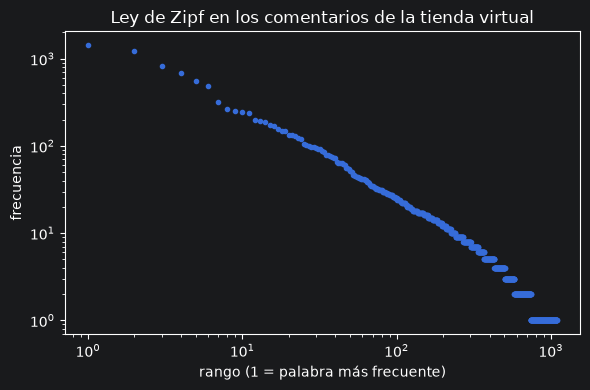

In [6]:
import re
from collections import Counter

import matplotlib.pyplot as plt

comentarios = pd.read_csv("../data/comentarios.csv")
palabras = re.findall(r"[a-záéíóúñü]+", " ".join(comentarios["texto_comentario"]).lower())

conteo = Counter(palabras)
mas_comunes = conteo.most_common()
rangos = np.arange(1, len(mas_comunes) + 1)
frecuencias_reales = np.array([f for _, f in mas_comunes])

print("Top 10 más frecuentes:", mas_comunes[:10])

plt.figure(figsize=(6, 4))
plt.loglog(rangos, frecuencias_reales, marker=".", linestyle="none")
plt.xlabel("rango (1 = palabra más frecuente)")
plt.ylabel("frecuencia")
plt.title("Ley de Zipf en los comentarios de la tienda virtual")
plt.tight_layout()
plt.show()

Un puñado de palabras funcionales domina el corpus y el resto forma una cola
larga de términos raros: exactamente el patrón que hace que "contar
palabras" (`02_bag-of-words.ipynb`) no baste por sí solo, y que motiva
ponderar por rareza en `03_tfidf.ipynb`.

**Siguiente:** `02_bag-of-words.ipynb` — construir el primer vector real a
partir del corpus de trabajo.